<a href="https://colab.research.google.com/github/Shahida-Rimu/Neural-Networks-Lab/blob/main/NN_ASS3_1091.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#Task 1: Data Exploration & Preprocessing


In [35]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

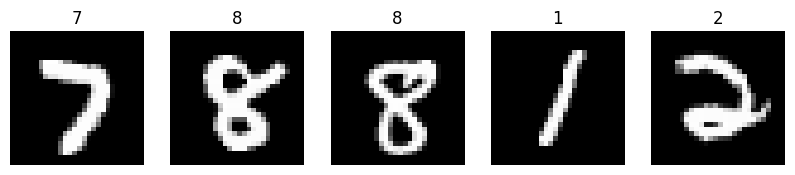

In [36]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(labels[i].item())
    plt.axis('off')
plt.show()

In [37]:
print("Train dataset size:", len(train_dataset))
print("Image shape:", train_dataset[0][0].shape)

Train dataset size: 60000
Image shape: torch.Size([1, 28, 28])


#Task 2: Architecture Design

In [39]:
class ModelA(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 32),
            nn.ReLU(),
            nn.Linear(32, 10)
        )
    def forward(self, x): return self.net(x)

class ModelB(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

class ModelC(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)


In [40]:
def train_model(model, epochs=10):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        train_losses.append(running_loss / len(train_loader))

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_losses.append(val_loss / len(test_loader))

    return train_losses, val_losses

In [ ]:
models = {
    "A": ModelA(),
    "B": ModelB(),
    "C": ModelC()
}

results = {}

for name, model in models.items():
    print(f"Training Model {name}")
    start = time.time()
    train_loss, val_loss = train_model(model)
    end = time.time()

    results[name] = {
        "model": model,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "time": end - start
    }

Training Model A
Training Model B
Training Model C


In [ ]:
for name in results:
    plt.plot(results[name]['train_loss'], label=f"{name} Train")
    plt.plot(results[name]['val_loss'], linestyle='--', label=f"{name} Val")

plt.legend()
plt.title("Loss Comparison")
plt.show()

#Task 3: Underfitting vs Overfitting

In [ ]:
class SmallModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 4),
            nn.ReLU(),
            nn.Linear(4, 10)
        )
    def forward(self, x): return self.net(x)

class LargeModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,1024),
            nn.ReLU(),
            nn.Linear(1024,512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self, x): return self.net(x)

#Task 4: Batch Normalization

In [ ]:
class ModelBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x): return self.net(x)

#Task 5: Error Analysis

In [ ]:
all_preds = []
all_labels = []

model = results["C"]["model"]

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [ ]:
misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                misclassified.append((images[i], preds[i], labels[i]))

# Show 10
plt.figure(figsize=(10,3))
for i in range(10):
    img, pred, true = misclassified[i]
    plt.subplot(2,5,i+1)
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"P:{pred} T:{true}")
    plt.axis('off')
plt.show()

#Task 6: Model Efficiency Table

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())

def calculate_accuracy(model, data_loader):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# Calculate accuracy for each model and add it to the results dictionary
for name, model_data in results.items():
    model = model_data["model"]
    accuracy = calculate_accuracy(model, test_loader)
    results[name]["accuracy"] = accuracy

print("Model | Params | Accuracy | Time")
for name in results:
    print(name,
          count_params(results[name]["model"]),
          f"{results[name]['accuracy']:.2f}%",
          f"{results[name]['time']:.2f}s")

In [ ]:
#Bonus

class DeepMLP(nn.Module):
    def __init__(self, use_bn=False):
        super().__init__()
        layers = [nn.Flatten()]
        size = 256

        for _ in range(8):
            layers.append(nn.Linear(size, size))
            if use_bn:
                layers.append(nn.BatchNorm1d(size))
            layers.append(nn.ReLU())

        layers.append(nn.Linear(size, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)